<a href="https://www.kaggle.com/code/yyanflores/exercise-2-classification-task-1?scriptVersionId=280441622" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from IPython.display import HTML, display

display(HTML('''
<div style="
    display:flex;
    justify-content: center;
    align-items: center;
    flex-direction:column;
    text-align: center;
    margin-top:10px;
    margin-bottom:10px;
    ">
<div style="
    padding:30px 40px;
    border-radius:20px;
    backdrop-filter:blur(6px);
    background:rgba(255,255,255,0.08);
    border:1px solid rgba(255, 255, 255, 0.12);
    box-shadow: 0 8px 30px rgba(0,0,0,0.25);
    max-width:700px
">
<h1 style="
    font-family:'Inter', system-ui, sans-serif;
    font-size: 50px;
    font-weight:800;
    background:linear-gradient(80deg,#50c878,#32CD32);
    -webkit-background-clip:text;
    background-clip:text;
    color:transparent;
    text-shadow: 0 25px 10px rgba(123,45,67,0.2)
    letter-spacing:-1px;
    margin:0px;
">
Animal Condition Classification
</h1>
</div>
</div>

'''))

**In this Kaggle Notebook, I analyzed data from the Animal Condition Classification, which has over 800 rows. The goal of this machine-learning project is to classify whether the condition is dangerous for the animal or not.**

### ***Importing Libraries***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tabulate import tabulate #to make tables
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, classification_report, roc_curve, auc, 
                            precision_recall_curve)

### ***Load Dataset***

In [3]:
df = pd.read_csv("/kaggle/input/animal-data/data.csv")

print("Dataset Preview:")
df.head(800)

Dataset Preview:


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes
...,...,...,...,...,...,...,...
795,Donkey,Nosebleed,Trauma,mild weakness,Nose picking,Dry air,Yes
796,Donkey,Bleeding from other parts of the body,confusion,Nasal discharge,loss of alertness,dizziness and fainting,Yes
797,Donkey,Bad breath,Pawing at the face or nose,cough,Sneezing,Bleeding from the nose,Yes
798,Donkey,extending its neck,gasping for air,gasping for breath,difficulty swallowing,gasping for breath,Yes


### ***Dataset Info***

In [4]:
print("\n Dataset Information")
print(tabulate([[df.shape[0], df.shape[1], df.isnull().sum().sum()]],
headers=["Total Rows", "Total Column", "Missing Values"], tablefmt='grid'))

df = df.dropna()


 Dataset Information
+--------------+----------------+------------------+
|   Total Rows |   Total Column |   Missing Values |
+==============+================+==================+
|          871 |              7 |                2 |
+--------------+----------------+------------------+


### ***Distribution***

In [5]:
target = df.columns[-1]
x = df.drop(columns=[target])
y = df[target]

print("Class Distribution")
print(tabulate(y.value_counts().reset_index().rename
               (columns={"index": "Class", target: "Count"}),headers="keys",
        tablefmt="fancy_grid"))


Class Distribution
╒════╤═════════╤═════════╕
│    │ Count   │   count │
╞════╪═════════╪═════════╡
│  0 │ Yes     │     849 │
├────┼─────────┼─────────┤
│  1 │ No      │      20 │
╘════╧═════════╧═════════╛


### ***Preprocessing***

In [6]:
# indentifying numerical and worded columns in the dataset
numerical = x.select_dtypes(include=[np.number]).columns.tolist()
worded = x.select_dtypes(exclude=[np.number]).columns.tolist()

#filling in the missing values
for col in numerical:
    x[col] = x[col].fillna(x[col].median())

for col in worded:
    x[col] = x[col].fillna(x[col].mode()[0])

x = pd.get_dummies(x, drop_first=True)

#Encoding
le = LabelEncoder()
y = le.fit_transform(y)




### ***Train and Test Split***


In [7]:
# Train
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

#because there are no numerical columns in the dataset, we are going to skip it
if len (numerical) > 0:
    print("Numerical Columns:", numerical)
    scaler = StandardScaler()
    x_train[numerical] = scaler.fit_transform(x_train[numerical])
    x_test[numerical] = scaler.transform(x_test[numerical])

else:
    print("No Numerical Colmuns, skipping... meow")

#Model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

results = {
    
}

No Numerical Colmuns, skipping... meow


### ***Prediction***

In [8]:
# to show how accurate the predition of the model is
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="binary")
recall = recall_score(y_test, y_pred, average="binary")
f1 = f1_score(y_test, y_pred, average="binary")

results[LogisticRegression] = {
    "model": model,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1" : f1,
    "pred": y_pred
}

table = [
    ["Accuracy", accuracy],
    ["Precision", precision],
    ["Recall", recall],
    ["F1 Score", f1]
]

print("Model Performance Metrics:")
print(tabulate(table, headers=["Metric", "Value"], tablefmt="fancy_grid"))

Model Performance Metrics:
╒═══════════╤══════════╕
│ Metric    │    Value │
╞═══════════╪══════════╡
│ Accuracy  │ 0.988506 │
├───────────┼──────────┤
│ Precision │ 0.988372 │
├───────────┼──────────┤
│ Recall    │ 1        │
├───────────┼──────────┤
│ F1 Score  │ 0.994152 │
╘═══════════╧══════════╛


### ***Visuallization***

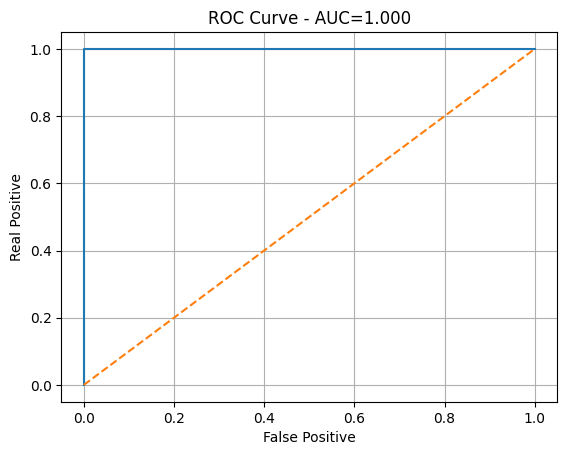

In [9]:
# visualizing with roc curve

y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.title(f"ROC Curve - AUC={roc_auc:.3f}")
plt.xlabel("False Positive")
plt.ylabel("Real Positive")
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

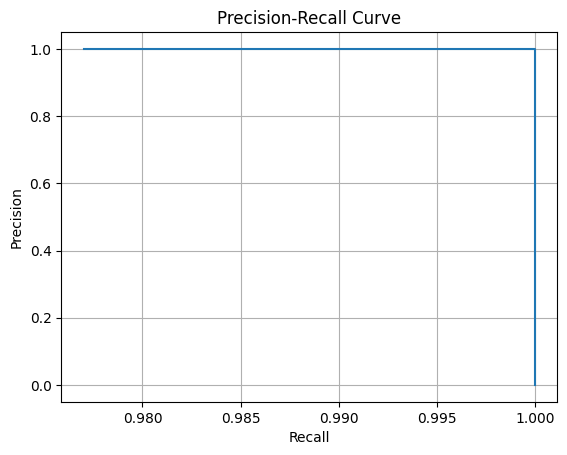

In [10]:
# visualizing with precision-recall curve

precisionVal, recallVal, _ = precision_recall_curve (y_test, y_proba)

plt.plot(precisionVal, recallVal)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show

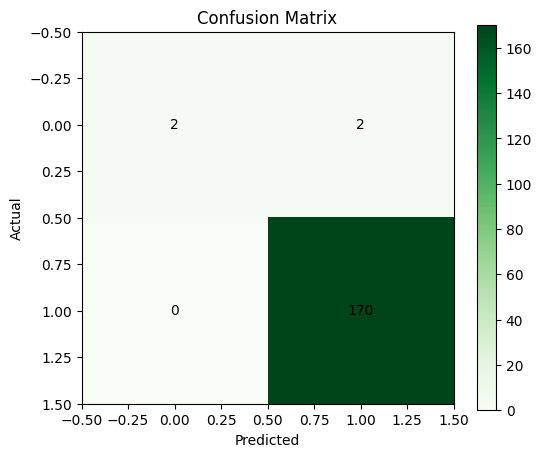

In [11]:
# visualizing with confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for (a, b), value in np.ndenumerate(cm):
    plt.text(b, a, value, ha='center', va='center')

plt.colorbar()
plt.show()
